In [1]:
from monai.apps import DecathlonDataset
from monai.data import DataLoader
import os
from monai.transforms import (
    LoadImageD,
    EnsureChannelFirstD,
    Compose,
    OrientationD,
)
import random
import matplotlib.pyplot as plt
import torch
import pickle as pkl
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, IncrementalPCA
from tqdm import tqdm
from sklearn.cluster import DBSCAN, KMeans

In [2]:
random.seed(0)

In [6]:
crt_dir = os.getcwd()
datasets_path = f'{crt_dir}/datasets/MSD/MedicalDecathlon/'
datasets_path

'/home/aimas/Desktop/Disertatie_CataChiru/LungCancerCT/datasets/MSD/MedicalDecathlon/'

In [7]:
base_transform = Compose([
    LoadImageD(keys=["image", "label"]),
    EnsureChannelFirstD(keys=["image", "label"]),
    OrientationD(keys=["image", "label"], axcodes='RAS'),
])

In [8]:
train_dataset = DecathlonDataset(root_dir = datasets_path,
                        task = "Task06_Lung", section = "training",
                        transform = base_transform, download = False)

Loading dataset:   0%|          | 0/51 [00:00<?, ?it/s]

Loading dataset: 100%|██████████| 51/51 [03:31<00:00,  4.15s/it]


In [9]:
def render_image(image, img_slice):
    plt.imshow(image[0, ..., img_slice])
    plt.axis('off')
    plt.show()

In [10]:
pacient = train_dataset[0]
print(pacient['image'].shape)

torch.Size([1, 512, 512, 589])


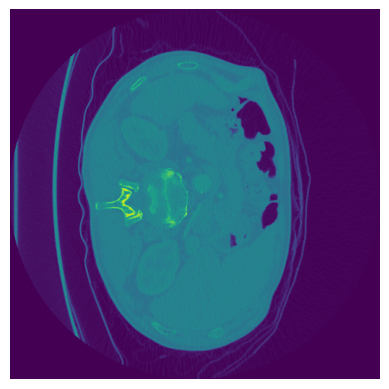

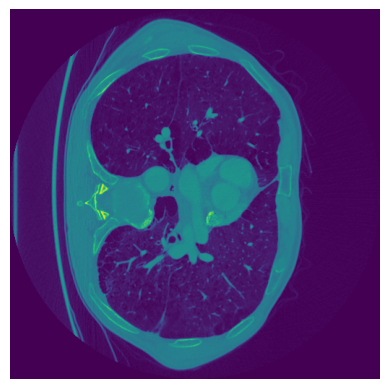

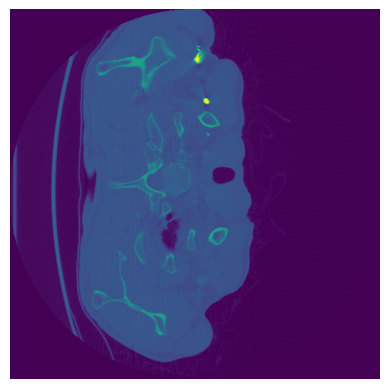

In [11]:
abdomen = pacient['image'][0, ..., 50]
lungs = pacient['image'][0, ..., 300]
neck = pacient['image'][0, ..., 550]


render_image(pacient['image'], 50)
render_image(pacient['image'], 300)
render_image(pacient['image'], 550)

# Treating Var Threshold as a hyperparameter

* Have tested: Var threshold = (90 -> 6 PC, 97.5 -> 28 PC, 98 -> 33 PC, 99 -> 50 PC, 99.5 -> 72 PC)

* Best trade-off between number of PC and image quality is: 99


In [12]:
def min_max_normalization(image):
    '''
    Min-max normalization to move the pixel values to [0,1]
    '''
    image = (image - image.min()) / (image.max() - image.min())
    
#     image = (image - image.mean()) / image.std()


    # If the image is a tensor image.float, else image.astype(np.float32)
    if isinstance(image, torch.Tensor):
        image = image.float()
    elif isinstance(image, np.ndarray):
        image = image.astype(np.float32)
        
    return image


In [21]:
def plot_pca_analysis(img, var_threshold, norm= True):
    image_bw = img
    print(image_bw.shape)

    if norm:
        image_bw = min_max_normalization(image_bw)
    print(image_bw.max())

    pca = PCA()
    pca.fit(image_bw)

    # Getting the cumulative variance
    var_cumu = np.cumsum(pca.explained_variance_ratio_)*100

    # How many PCs explain x% of the variance?
#     var_threshold = 90
    # var_threshold = 70

    k = np.argmax(var_cumu>var_threshold)
    print(f"Number of components explaining {var_threshold}% variance: "+ str(k))

    plt.figure(figsize=[10,5])
    plt.title('Cumulative Explained Variance by the number of components')
    plt.ylabel('Cumulative Explained variance')
    plt.xlabel('Principal components')
    plt.axvline(x=k, color="k", linestyle="--")
    plt.axhline(y=var_threshold, color="r", linestyle="--")
    ax = plt.plot(var_cumu)
    plt.show()
    
    ipca = IncrementalPCA(n_components=k)
    image_recon = ipca.inverse_transform(ipca.fit_transform(image_bw))

    if norm:
        image_recon = 255*min_max_normalization(image_recon)
    else:
        image_recon = 255 * image_recon
    
    
    fig, axes = plt.subplots(1,2, figsize=[12,8])
    for ax in axes:
        ax.set_axis_off()
        
                
    axes[0].imshow(image_recon)
    axes[0].set_title('Reconstructed Image from PCA')
    
    axes[1].imshow(img)
    axes[1].set_title('Original Image')
    plt.show()

torch.Size([512, 512])
metatensor(1449.)
Number of components explaining 99% variance: 50


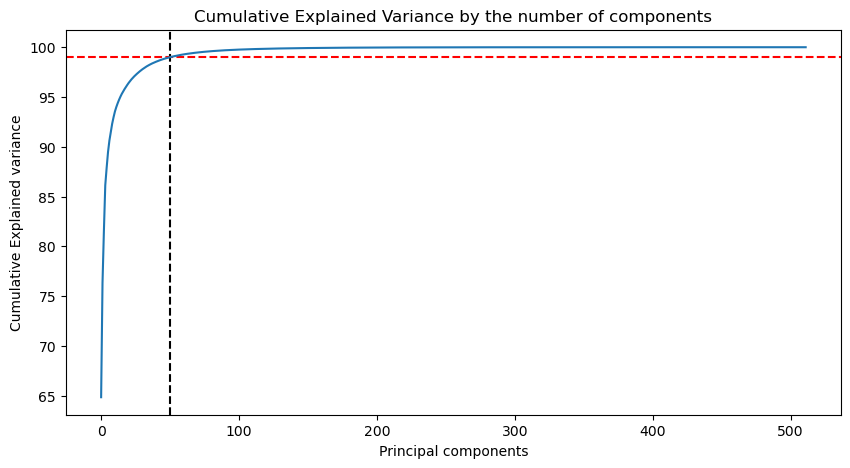

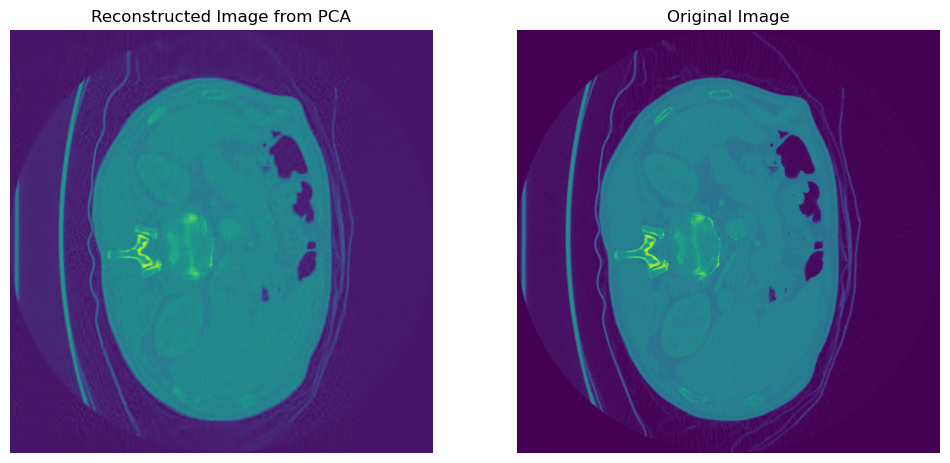

In [22]:
plot_pca_analysis(abdomen, 99, norm= False)

# Treating No of Principal Components as the hyperparameter

* We chosed 3 random patients and averaged the number of PC needed for 99% variation

* The mean is 155.645, we truncated to 150 components to be taken further for Clusterization for each slice

In [63]:
rand_idx = [ ]

for i in range(4):
    next_idx = random.randint(0, len(train_dataset) - 1)
    if next_idx in rand_idx:
        continue
    rand_idx.append(next_idx)

rand_train = []

for idx in rand_idx:
    rand_train.append(train_dataset[idx])
    
rand_idx

[12, 15, 1, 46]

In [64]:
rand_train[0]['image'].shape

torch.Size([1, 512, 512, 115])

In [61]:
def pca_slice(image, var_threshold= 99, norm= True):
    if norm:
        image_bw = min_max_normalization(image)
    else:
        image_bw = image
    
    pca = PCA()
    pca.fit(image_bw)

    var_cumu = np.cumsum(pca.explained_variance_ratio_)*100

    k = np.argmax(var_cumu>var_threshold)
    
    return k

In [62]:
def calculate_mean_components(pacients):
    
    components = []
    for idx, dt in tqdm(enumerate(pacients)):
        img = dt['image'].squeeze(0)
        for slc in tqdm(range(img.shape[-1])):
            components.append(pca_slice(img[..., slc], norm= True))
        
    return components

In [90]:
components = calculate_mean_components(rand_train)

0it [00:00, ?it/s]
 32%|█████████████▌                            | 96/296 [02:20<05:52,  1.76s/it]


 65%|██████████████████████████▋              | 193/296 [04:40<02:15,  1.31s/it]


 98%|████████████████████████████████████████▏| 290/296 [06:50<00:07,  1.19s/it]


100%|█████████████████████████████████████████| 296/296 [06:58<00:00,  1.41s/it]
1it [06:58, 418.26s/it]
 40%|████████████████▋                         | 90/226 [02:06<03:08,  1.39s/it]


 83%|█████████████████████████████████▉       | 187/226 [04:13<00:54,  1.41s/it]


100%|█████████████████████████████████████████| 226/226 [05:00<00:00,  1.33s/it]
2it [11:59, 349.14s/it]
 24%|█████████▉                                | 57/242 [01:22<04:31,  1.47s/it]


 64%|██████████████████████████               | 154/242 [03:29<01:20,  1.09it/s]


100%|█████████████████████████████████████████| 242/242 [05:39<00:00,  1.40s/it]
3it [17:38, 352.85s/it]


In [91]:
len(components)

764

In [93]:
np.array(components).mean()

155.64528795811518

# Applyin Clustering Methods on those patients

In [66]:
def pca_singural_values(image, taken_components= 150, norm= True):
    if norm:
        image_bw = min_max_normalization(image)
    else:
        image_bw = image
    
    pca = PCA()
    pca.fit(image_bw)

    return pca.singular_values_[:taken_components]

In [67]:
def get_pacients_pca_components(patients):
    
    pacient_components = []
    
    for idx, dt in tqdm(enumerate(patients)):
        
        img = dt['image'].squeeze(0)
        for slc in tqdm(range(img.shape[-1])):
            crt_pacient = [rand_idx[idx], slc]
            crt_pacient.append(pca_singural_values(img[..., slc], norm= True))
            pacient_components.append(crt_pacient)
            
    
    return pacient_components

In [68]:
components_patient_info = get_pacients_pca_components(rand_train)

100%|██████████| 242/242 [04:06<00:00,  1.02s/it]
4it [15:15, 228.89s/it]


In [30]:
def apply_clustering(components_patient_info, eps = 1):
    
#     components = get_pacients_pca_components(dataset)
    
    components = [comp[2] for comp in components_patient_info]
    
    dbscan = DBSCAN(eps = eps).fit(components)
    
    return dbscan

In [31]:
dbscan = apply_clustering(components_patient_info, eps = 4.5)

np.unique(dbscan.labels_)

array([-1])

In [124]:

# No clusters per distance



# < 0.5 => 1
# 0.7 => 6
# [0.8, 0.9] => 14
# [1, 2.5] => 18
# 3 => 5
# 4 => 2
# > 4 => 1


# 5, 10, 15, 20

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18])

In [32]:
def apply_kmeans(components_patient_info, clusters = 5):
    
    components = [comp[2] for comp in components_patient_info]
    
    kmeans = KMeans(n_clusters=clusters).fit(components)

    return kmeans

In [33]:
kmeans = apply_kmeans(components_patient_info, 5)

In [40]:
# components_patient_info = np.array(components_patient_info)
# X = components_patient_info[kmeans.labels_ == 1]
label_indices = np.nonzero(kmeans.labels_ == 0)

for idx in label_indices[0]:
    img = train_dataset[components_patient_info[idx][0]]['image']
    render_image(img, components_patient_info[idx][1])


In [41]:
def get_image_and_label(data):
    transformed = base_transform(data)
    transf_label = data['seg'].permute(1, 2, 3, 0)
    
    return data['image'], transf_label[..., 1].unsqueeze(0)

In [85]:
def plot_clusters(components_patient_info, NO_CLUSTERS, NO_IMAGES = 6):
    fig, axes = plt.subplots(NO_CLUSTERS, NO_IMAGES, figsize=[20, 5])

    for i in range(NO_CLUSTERS):
        label_indices = np.nonzero(kmeans.labels_ == i)

        # Randomly select NO_IMAGES images from the cluster
        random_indices = random.sample(list(label_indices[0]), NO_IMAGES)

        # Put the title to the left
        axes[i, 0].yaxis.set_label_position("left")
        axes[i, 0].set_ylabel(f'Cluster {i}')


        for j, idx in enumerate(random_indices):
            metadata = components_patient_info[idx]
            patient_id, slice_idx = metadata[0], metadata[1]
            patient_volume = train_dataset[patient_id]['image']

            img = patient_volume[0, ..., slice_idx]
            axes[i, j].imshow(img, cmap='gray')
            # axes[i, j].set_title(f'Cluster {i} - Image {j}')
            axes[i, j].set_axis_off()
        
    plt.tight_layout()
    plt.show()

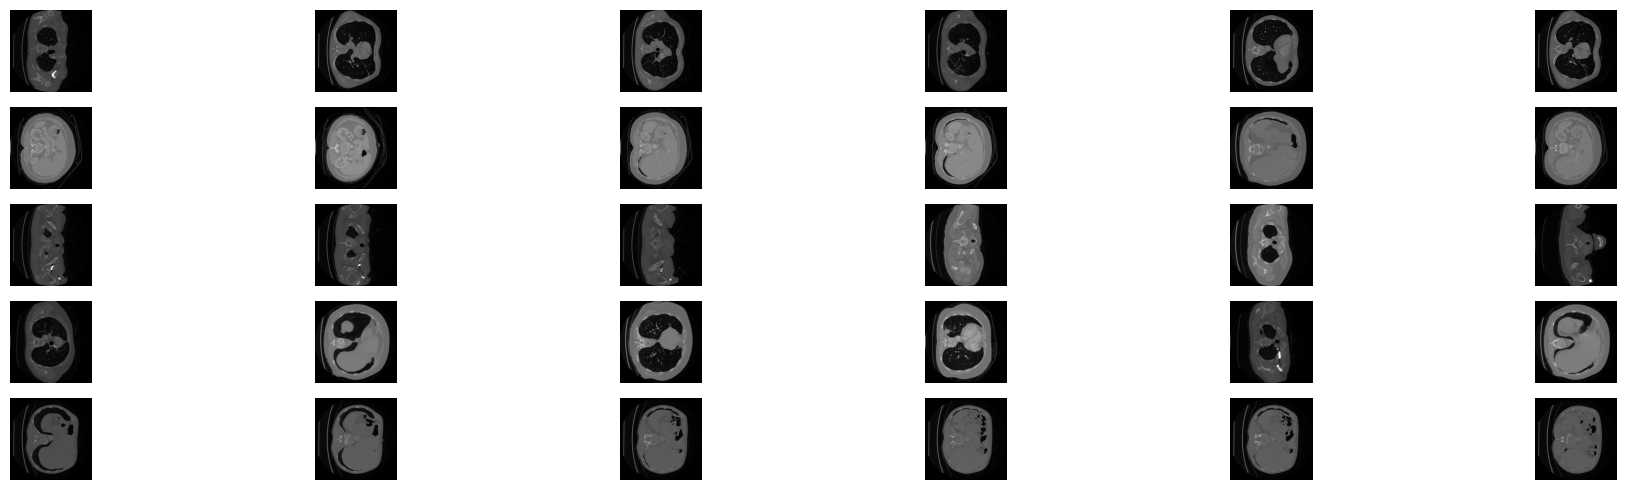

In [52]:
plot_clusters(components_patient_info, 5)

In [92]:
LAST_TRAIN_SLICE = 671

In [93]:
kmeans = apply_kmeans(components_patient_info[:LAST_TRAIN_SLICE], 2)

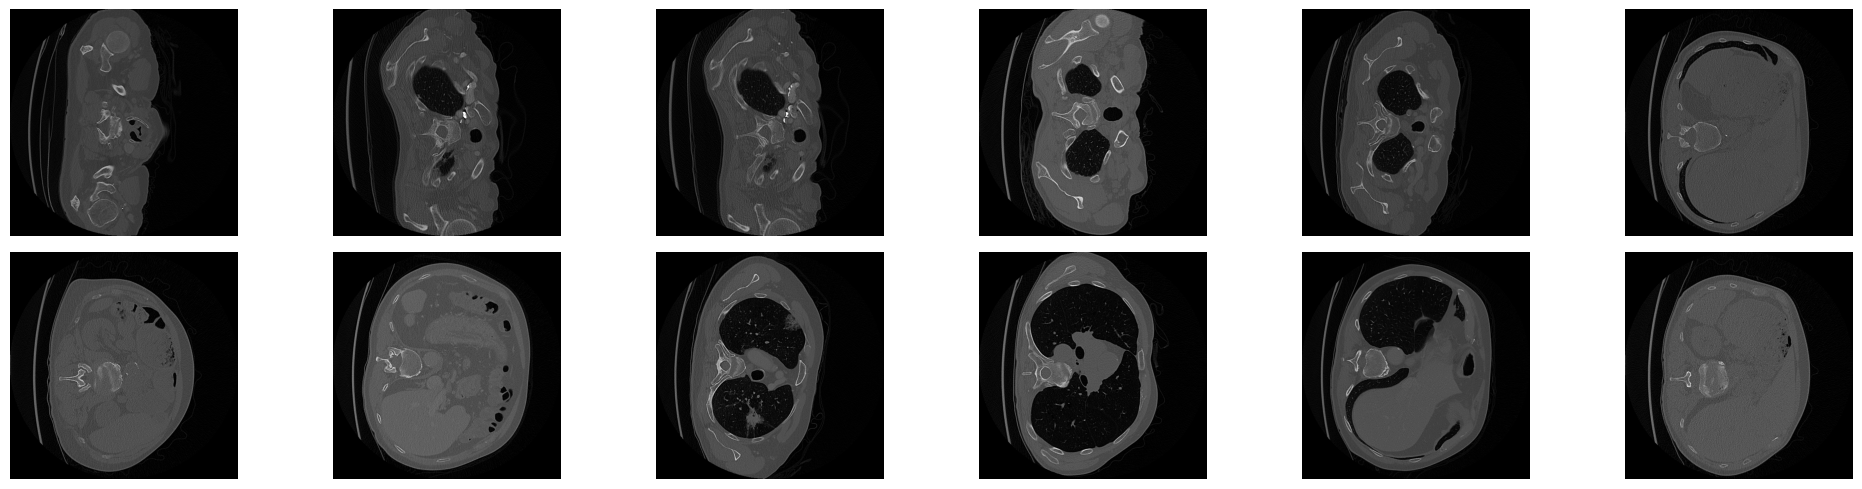

In [95]:
plot_clusters(components_patient_info[:LAST_TRAIN_SLICE], 2)

In [84]:
print(len(components_patient_info))

913


In [96]:
def predict_kmeans(kmeans, components_patient_info):
    
    components = [comp[2] for comp in components_patient_info]

    prediction = kmeans.predict(components)

    return prediction

In [99]:
prediction = predict_kmeans(kmeans, components_patient_info[LAST_TRAIN_SLICE:])

In [104]:
print(len(prediction))
print(prediction)

242
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [109]:
kmeans.cluster_centers_[0]

array([27.3034513 , 17.88248511, 12.5736172 , 10.2102461 ,  8.60337222,
        7.56422727,  6.80286156,  6.23682324,  5.71797851,  5.31168778,
        4.95210341,  4.6847072 ,  4.4416841 ,  4.25311468,  4.06456667,
        3.88957216,  3.74686875,  3.61613992,  3.499372  ,  3.38785893,
        3.28810903,  3.19975827,  3.11320186,  3.03675338,  2.96374171,
        2.89348069,  2.83362177,  2.77241796,  2.7151789 ,  2.65910002,
        2.6021545 ,  2.5537746 ,  2.50809787,  2.46007355,  2.41516076,
        2.37535341,  2.33400579,  2.29700486,  2.25658246,  2.21919199,
        2.18200726,  2.1473056 ,  2.11353836,  2.08248958,  2.0493893 ,
        2.02077145,  1.99160012,  1.96177942,  1.93310903,  1.90585198,
        1.87970919,  1.85507719,  1.82964784,  1.80498665,  1.78202969,
        1.7589044 ,  1.7348743 ,  1.71176744,  1.69028663,  1.6686055 ,
        1.64697477,  1.62814889,  1.60726685,  1.58732902,  1.56960956,
        1.55018978,  1.53255325,  1.51482916,  1.49667096,  1.47

In [116]:
def plot_large_grid(vect, prediction, cluster= 0):
    length = vect.shape[-1]
    # length = len(prediction)

    rows = int(np.sqrt(length)) + 1
    cols = int(length / rows) + 1
    
    print(rows, cols)
    
    
    fig, ax = plt.subplots(rows, cols)

    fig.set_figheight(15)
    fig.set_figwidth(15)

    break_flag = False

    for i in range(rows):
        if break_flag:
            break

        for j in range(cols):
            crt_idx = cols*i + j 
            if crt_idx >= length:
#                 print(crt_idx)
#                 print(i, j)
                break_flag = True
                break
            
            if prediction[crt_idx] == cluster:
                ax[i, j].imshow(vect[0, ..., crt_idx])
                ax[i, j].axis("off")
    plt.tight_layout()        
    plt.show()

16 16


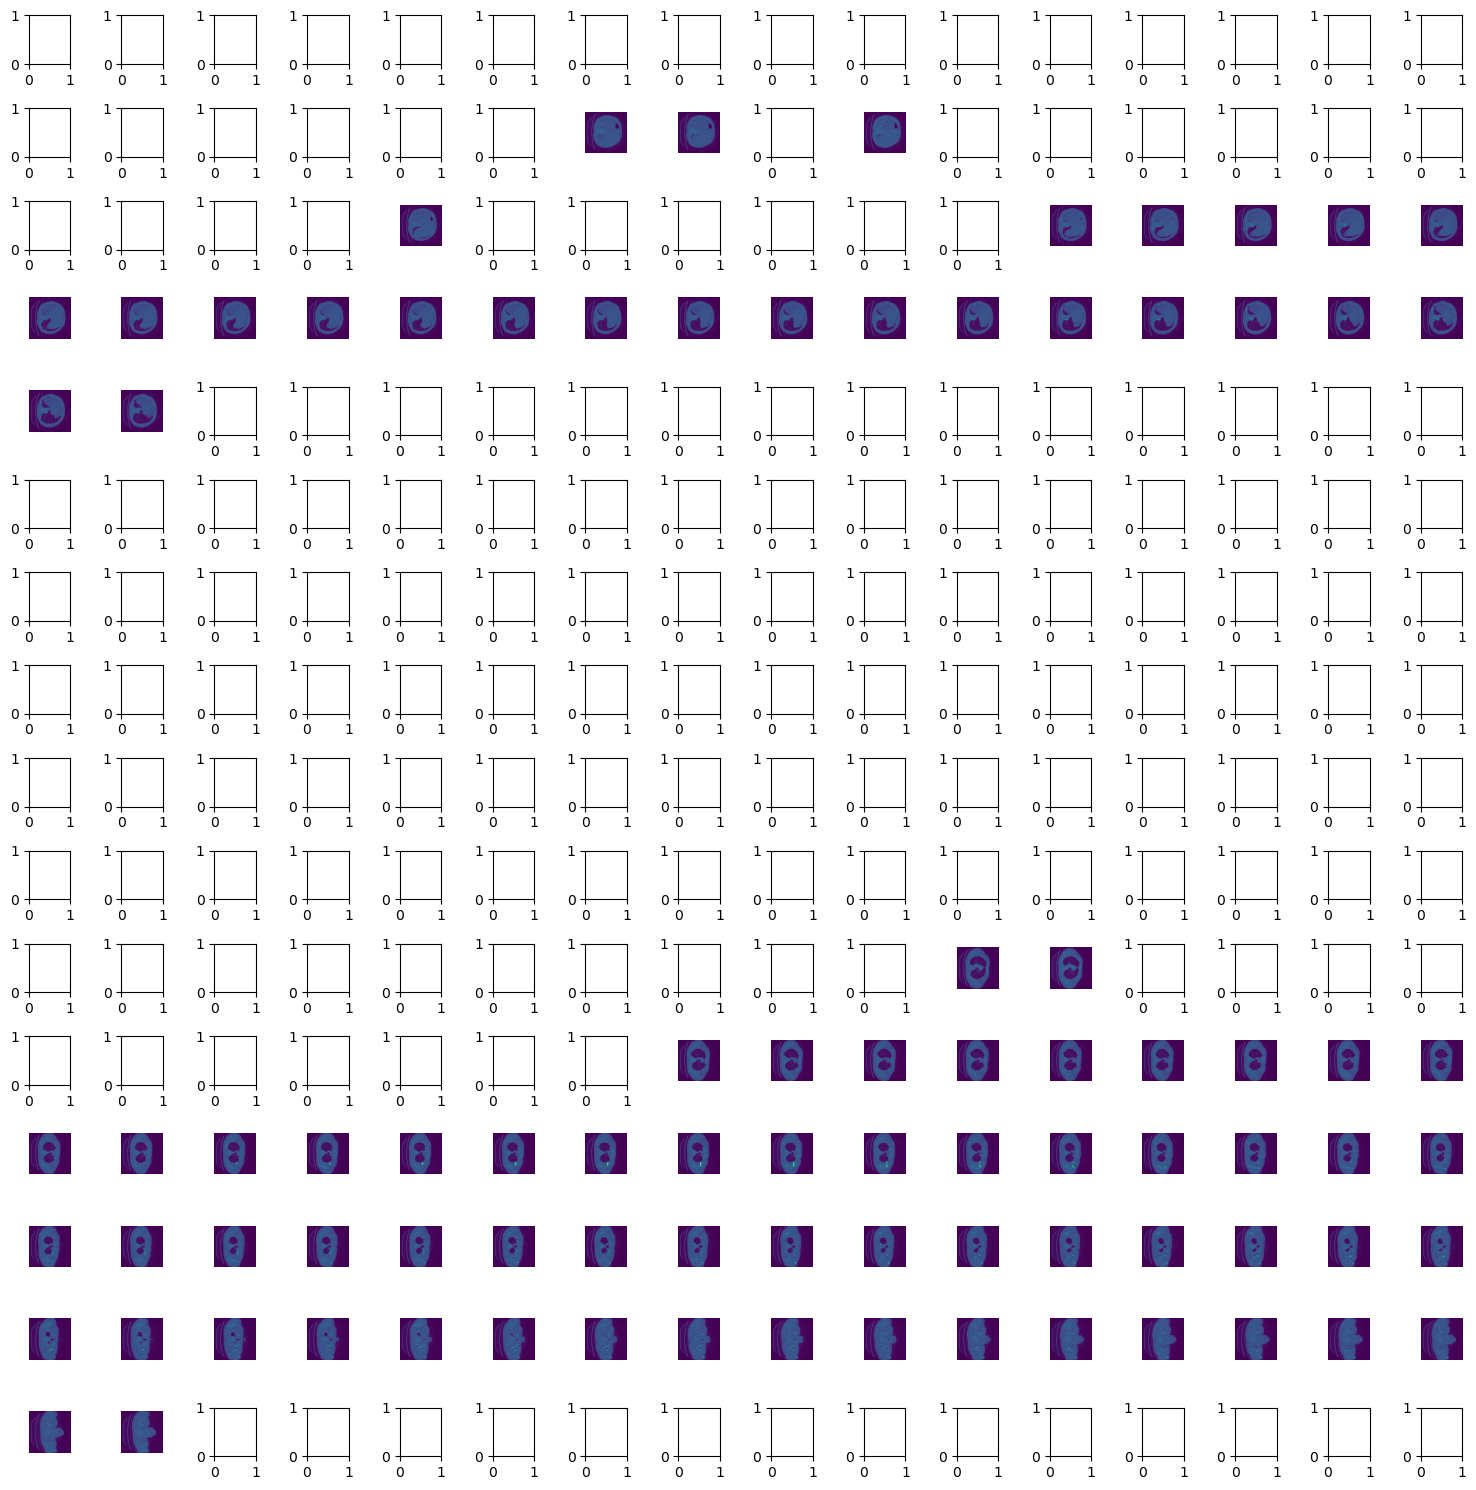

In [119]:
plot_large_grid(rand_train[3]['image'], prediction, cluster= 0)

16 16


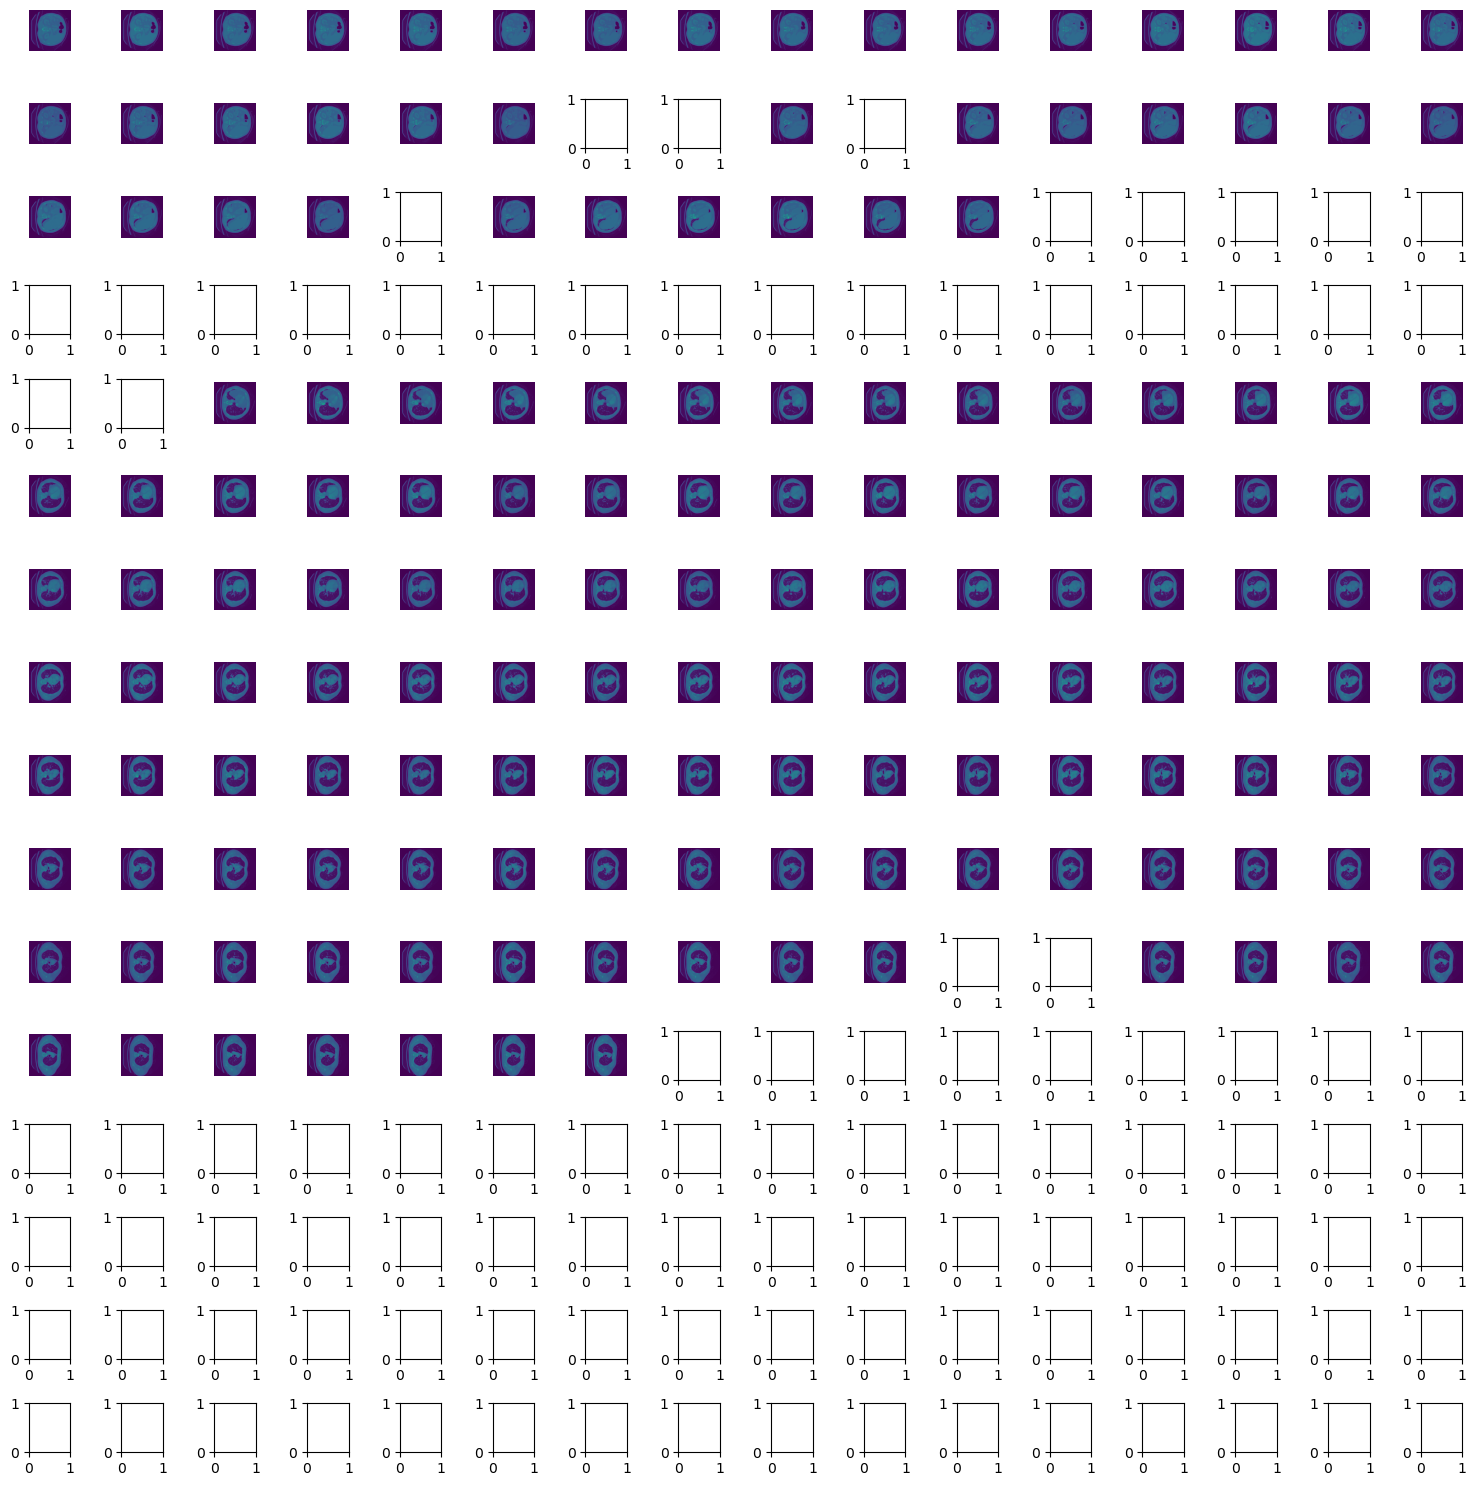

In [120]:
plot_large_grid(rand_train[3]['image'], prediction, cluster= 1)